# Experiment 3.2 (bimodal field), three ways

The **missing cell** of the 2x2: a nonconvex prior at *field dimension* ($n=64$),
where the inversion is no longer exact but an Adam solve -- the same inverter,
learning rate and $\alpha$ that `tv_pm/prior_routes` uses.

|  | $f_{reg}$ **convex** | $f_{reg}$ **nonconvex** |
|---|---|---|
| **1-D, exact inversion** | -- | Exp 1: Iterative beats One-shot |
| **64-D, iterative solver** | TV: Direct fit wins | **this run** |

Together with the TV experiment this separates the two axes the paper argues
about: *is there a recovery step?* and *which class is $J$ in?*

> **Runtime.** `PRESET = "full"` trains three 256-wide networks for 50,000 steps
> and then scores them with 20,000-iteration inversions -- **hours** on CPU. Start
> with `"smoke"`. Checkpoints are cached, so `FORCE = False` reuses any existing
> `results/ckpt/threeway_bimodal_*.pth` and only re-scores.


## 1. Configuration

In [29]:
PRESET = "full"      # "smoke" (~minutes)  |  "full" (hours on CPU)
SIGMA  = 0.5
FORCE  = True        # True: retrain even if a checkpoint exists

SMOKE = (PRESET == "smoke")
if SMOKE:
    print("NOTE: smoke is a PLUMBING CHECK -- 400 steps. The numbers it prints are")
    print("      not meaningful; use PRESET = 'full' before reading any result.")
    print("")
if not FORCE:
    print("WARNING: checkpoint filenames encode ONLY sigma -- not steps, hidden or")
    print("         beta. With FORCE = False a cached net trained under a DIFFERENT")
    print("         config is silently reused. Set FORCE = True after changing any")
    print("         network knob in the overrides cell.")
    print("")
print(f"preset {PRESET}, sigma {SIGMA}, force {FORCE}")


preset full, sigma 0.5, force True


In [30]:
import os, sys, importlib, time

# Notebooks have no __file__, so anchor the paths by walking up for the repo
# root -- the directory that contains BOTH src/ and pnp_reg/.
ROOT = os.path.abspath(os.getcwd())
while not (os.path.isdir(os.path.join(ROOT, "src"))
           and os.path.isdir(os.path.join(ROOT, "pnp_reg"))):
    parent = os.path.dirname(ROOT)
    assert parent != ROOT, "repo root not found -- open this notebook inside the repo"
    ROOT = parent

# src.* needs the root; pnpreg.* needs pnp_reg/ itself.
for p in (ROOT, os.path.join(ROOT, "pnp_reg")):
    if p not in sys.path:
        sys.path.insert(0, p)

RESULTS = os.path.join(ROOT, "pnp_reg", "results")
print("repo root :", ROOT)
print("results   :", RESULTS)
print("python    :", sys.executable)


repo root : /Users/oluwatosin/Downloads/lpn_for_nonconvex_control
results   : /Users/oluwatosin/Downloads/lpn_for_nonconvex_control/pnp_reg/results
python    : /opt/anaconda3/envs/lpn_env_image/bin/python


## 2. Import the experiment

In [31]:
from pnpreg import bimodal_run as br
from pnpreg import threeway_bimodal as tb
importlib.reload(tb)          # picks up edits to threeway_bimodal.py

print("network / training config (shared with Experiment 3.2):")
for k, v in br.CFG.items():
    print(f"  {k:9s} {v}")
print("\ninversion (the Iterative route only):")
print(f"  iters     {tb.INVERT_ITERS}")
print(f"  lr        {tb.INVERT_LR}")
print(f"  alpha     {tb.ALPHA}")

ck = os.path.join(RESULTS, "ckpt")
have = sorted(f for f in os.listdir(ck) if f.startswith("threeway_bimodal")) \
    if os.path.isdir(ck) else []
print("\ncached checkpoints:", have or "none")
print("=> will", "RETRAIN (FORCE=True)" if FORCE else
      ("reuse the cache" if have else "train from scratch"))


network / training config (shared with Experiment 3.2):
  hidden    256
  layers    2
  beta      20
  batch     512
  steps     50000
  n_train   40000
  n_val     8000
  n_eval    4000

inversion (the Iterative route only):
  iters     20000
  lr        0.01
  alpha     0.0

cached checkpoints: ['threeway_bimodal_G_s0.5.pth', 'threeway_bimodal_direct_s0.5.pth', 'threeway_bimodal_psi_s0.5.pth']
=> will RETRAIN (FORCE=True)


## 3. Overrides (optional)

The inversion knobs are the interesting ones here: they are exactly what decides
whether the Iterative route wins or loses, and they do **not** affect the other
two methods.


In [32]:
# --- the inversion (Iterative route only) -------------------------------
# tb.INVERT_ITERS =20_000     # fewer iterations -> cheaper, and worse
# tb.INVERT_LR    = 1e-2      # pinned by the inversion's own certificate
# tb.ALPHA        = 0.0       # alpha > 0 regularizes the solve and BIASES the prior

# --- networks / data (shared by all three) ------------------------------
br.CFG["hidden"]  = 256
br.CFG["steps"]   = 50_000
br.CFG["n_train"] = 40_000

# The inversion memoizes on the query block; clear it after changing a knob.
tb._PRE.clear()

# br.CFG changes the NETWORKS -> any cached checkpoint is stale -> set FORCE=True.
# The tb.* inversion knobs affect scoring only and need no retrain.
print(f"iters {tb.INVERT_ITERS}, lr {tb.INVERT_LR}, alpha {tb.ALPHA}")
print({k: br.CFG[k] for k in ("hidden", "layers", "beta", "steps", "n_train")})


iters 20000, lr 0.01, alpha 0.0
{'hidden': 256, 'layers': 2, 'beta': 20, 'steps': 50000, 'n_train': 40000}


## 4. Train and score all three methods

In [ ]:
t0 = time.time()
out = tb.run(sigma=SIGMA, smoke=SMOKE, force=FORCE)
print(f"\ntotal {(time.time() - t0) / 60:.1f} min")


sigma=0.5 t=0.25  n_train=40000 steps=50000


## 5. Results table

In [ ]:
JSON_PATH = os.path.join(RESULTS, f"threeway_bimodal_s{SIGMA}.json")
EXACT_KEY = "exact_u_min_curv"
COLS = ["cost", "rel-L2", "u curvature", "perp L2", "resid median", "resid p90"]
FMT = {
    "cost":         lambda r: r["cost"],
    "rel-L2":       lambda r: f"{100 * r['rel_l2']:.2f}%",
    "u curvature":  lambda r: f"{r['u_min_curv']:+.4f}",
    "perp L2":      lambda r: f"{100 * r['perp_rel_l2']:.2f}%",
    "resid median": lambda r: f"{100 * r['resid_median']:.2f}%",
    "resid p90":    lambda r: f"{100 * r['resid_p90']:.2f}%",
}
import json
from IPython.display import Markdown, display

with open(JSON_PATH) as fh:
    out = json.load(fh)

hdr = ["method", "class"] + [c for c in COLS]
lines = ["| " + " | ".join(hdr) + " |",
         "|" + "|".join(["---"] * len(hdr)) + "|"]
for r in out["rows"]:
    cells = [r["method"], r["cls"]] + [FMT[c](r) for c in COLS]
    lines.append("| " + " | ".join(cells) + " |")
display(Markdown("\n".join(lines)))
print(f"exact min curvature: {out[EXACT_KEY]:+.4f}   (semiconvexity floor -1)")

inv = out["inversion"]
print(f"inversion certificate: median {inv['cert_median']:.2e}, max {inv['cert_max']:.2e}")
print(f"preimage max-norm    : {inv['preimage_linf']:.2f}"
      f"   (a solve leaving the fitted region reads high here)")


| method | class | cost | rel-L2 | u curvature | perp L2 | resid median | resid p90 |
|---|---|---|---|---|---|---|---|
| LPN Iterative recovery | 1-semiconvex | inversion/query | 1.70% | -0.8797 | 13.67% | 14.16% | 24.79% |
| One-shot recovery | 1-semiconvex | forward | 43.71% | -0.8695 | 0.52% | 3.20% | 4.62% |
| Direct fit | convex | forward | 17.31% | +0.0010 | 0.91% | 5.94% | 16.50% |

exact min curvature: -0.9113   (semiconvexity floor -1)
inversion certificate: median 9.12e-04, max 2.81e-03
preimage max-norm    : 2.40   (a solve leaving the fitted region reads high here)


**How to read it.** `u curvature` is the class test, as in Experiment 1: only the
convex class is unable to go below zero. The `resid` columns are the
ground-truth-free score -- median versus p90, because the median hides what
happens on the hard decile. The inversion certificate is printed separately so a
*failed solve* can be told apart from a *wrong prior*: a small certificate with a
large residual means the inversion converged to the wrong kind of object.


## 6. Figure

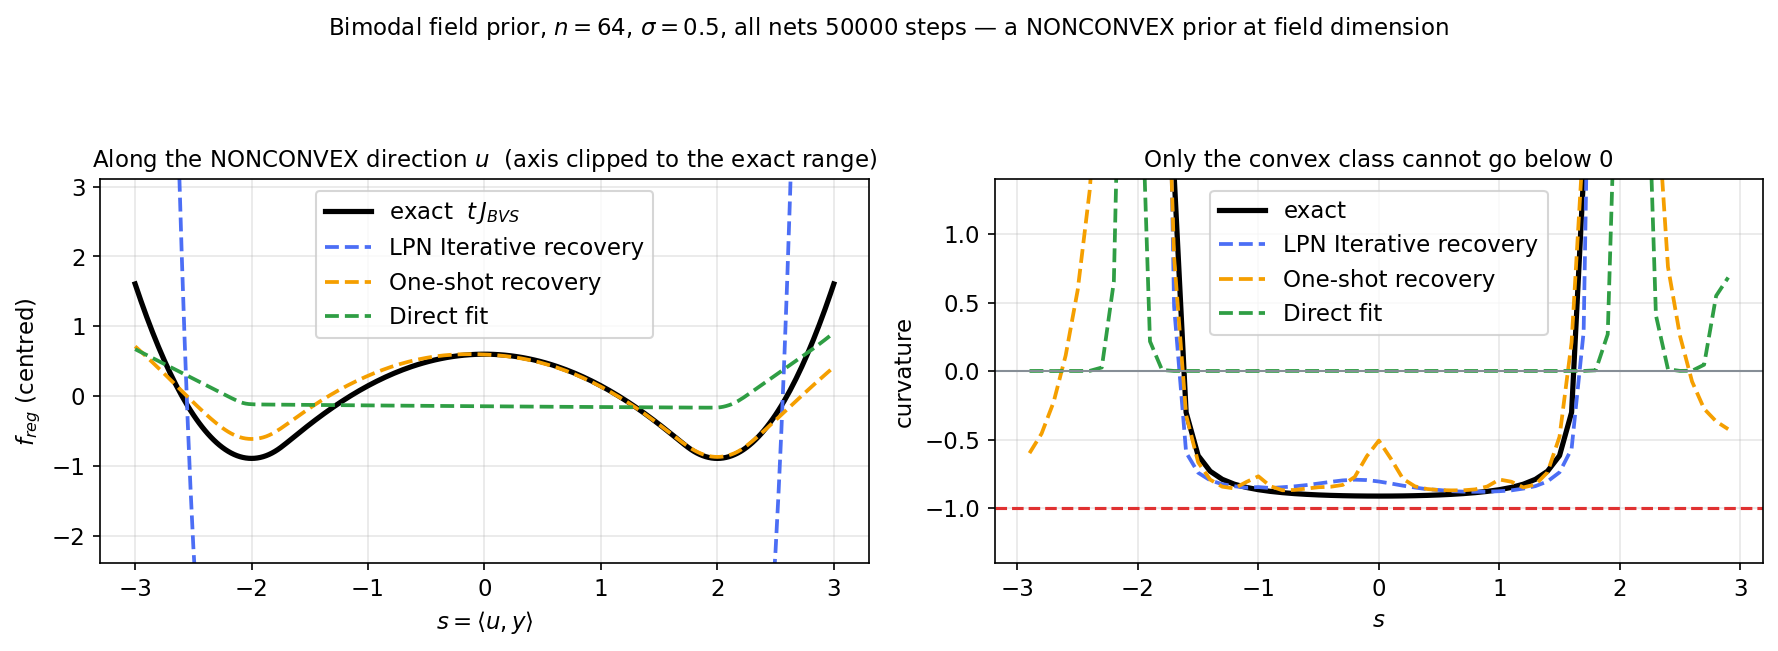

In [ ]:
FIG_PATH = os.path.join(RESULTS, "figs", f"threeway_bimodal_s{SIGMA}.png")
from IPython.display import Image, display
import os
if os.path.exists(FIG_PATH):
    display(Image(filename=FIG_PATH))
else:
    print("figure not found:", FIG_PATH)


## 7. Editing the experiment

Logic lives in `pnp_reg/pnpreg/threeway_bimodal.py`; re-run cell 2 after editing.

| function | what it does |
|---|---|
| `PsiInY` | wraps $\psi_\theta$ into y-units so `src/invert.py` works verbatim |
| `preimage` | memoized batched inversion (one Adam solve per query block) |
| `inversion_certificate` | $\|\nabla\psi(w)-y\| / \max(1,\|y\|)$ |
| `spectrum` | per-mode curvature, all queries stacked into ONE `gradf` call |
| `run` | data -> three fits -> metrics -> figure |

**Artifacts written** (all under `pnp_reg/results/`):

```
threeway_bimodal_s<SIGMA>.json
threeway_bimodal_curves_s<SIGMA>.npz
figs/threeway_bimodal_s<SIGMA>.png / .pdf
ckpt/threeway_bimodal_{psi,G,direct}_s<SIGMA>.pth
```

**Stale files to delete by hand.** A superseded attempt left three artifacts that
are easy to confuse with the live ones -- note `sigma0.5` versus `s0.5`:

```
pnp_reg/pnpreg/threeway_bimodal_final.py
pnp_reg/results/threeway_bimodal_final_s0.5.json
pnp_reg/results/threeway_bimodal_sigma0.5.json
```
